# How to use custom transforms in ClinicaDL?

The goal of this tutorial is to see how you can use your own transforms in ClinicaDL. This may interest you if you don't find what you want in [natively supported transforms](https://clinicadl.readthedocs.io/en/latest/transforms/transforms.html#supported-transforms).

## Introduction

As an example, we will implement a transform that generates hypointensities in a random mask on T1 MRI images.

In [7]:
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchio as tio

from clinicadl.data.datasets import CapsDataset
from clinicadl.data.datatypes import T1Linear
from clinicadl.data.structures import DataPoint
from clinicadl.transforms import Transforms

Let's define some useful functions:

In [8]:
def random_mask(img: torch.Tensor) -> torch.Tensor:
    """
    Generates a random mask (a rectangular prism) for a 4D tensor
    (with one channel dimension).

    Parameters
    ----------
    img : torch.Tensor
        The image.

    Returns
    -------
    torch.Tensor
        A random mask for the image.
    """
    center = np.array(img.shape[1:]) // 2
    radius = np.random.randint(1, center)
    mask = np.zeros_like(img)
    mask[
        :,
        (center - radius)[0] : (center + radius)[0],
        (center - radius)[1] : (center + radius)[1],
        (center - radius)[2] : (center + radius)[2],
    ] = 1
    return torch.from_numpy(mask).bool()

def random_hypo_coeff(min_hypo: float = 0.5) -> float:
    """
    Generates a random hypointensity coefficient.

    Parameters
    ----------
    min_hypo : float (optional, default=0.5)
        The minimal coefficient. The random hypointensity coefficient
        will be sample randomnly between 0 and ``min_hypo``.

    Returns
    -------
    torch.Tensor
        The hypointensity coefficient, i.e. the intensity reduction factor
        that will be applied in the mask.
    """
    return np.random.uniform(0, min_hypo)

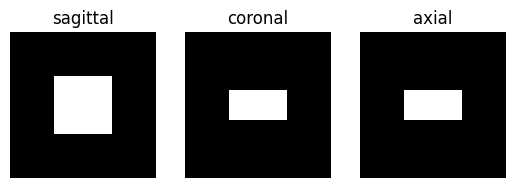

In [12]:
mask = random_mask_generator(torch.randn(1, 10, 10, 10))

fig, axes = plt.subplots(1, 3)
axes[0].imshow(mask[0, 5], cmap="gray")
axes[0].set_title("sagittal")
axes[0].set_axis_off()
axes[1].imshow(mask[0, :, 5], cmap="gray")
axes[1].set_title("coronal")
axes[1].set_axis_off()
axes[2].imshow(mask[0, :, :, 5], cmap="gray")
axes[2].set_title("axial")
axes[2].set_axis_off()

Now, let's define our transform.

A transform compatible with ClinicaDL is a simple callable, that takes as input a [DataPoint](https://clinicadl.readthedocs.io/en/latest/data/datapoint.html#clinicadl.data.structures.DataPoint) and returns a DataPoint. Check our documentation to know the useful methods to manipulate ``DataPoints``.

In [34]:
class RandomHypoIntensity(tio.Transform):
    """
    To generate random hypointensities in ClinicaDL.
    """

    def __init__(self, min_hypo: float = 0.5, **kwargs):
        super().__init__(**kwargs)
        self.min_hypo = min_hypo
        self.args_names = ["min_hypo"]

    def apply_transform(self, datapoint: DataPoint) -> DataPoint:
        transformed = deepcopy(datapoint)

        mask = random_mask(datapoint.image.tensor)
        hypo_coeff = random_hypo_coeff(self.min_hypo)

        # apply the hypointensity to all the images in DataPoint (but not the masks because intensity_only=True)
        for image in transformed.get_images(intensity_only=True):
            image.tensor[mask] *= hypo_coeff

        return transformed

Let's try our transform:

In [35]:
transform = RandomHypoIntensity()
data = tio.datasets.Colin27()
datapoint = DataPoint(
    image=data.t1, label=data.brain, participant="sub-colin", session="ses-M000"
)
transformed = transform(datapoint)

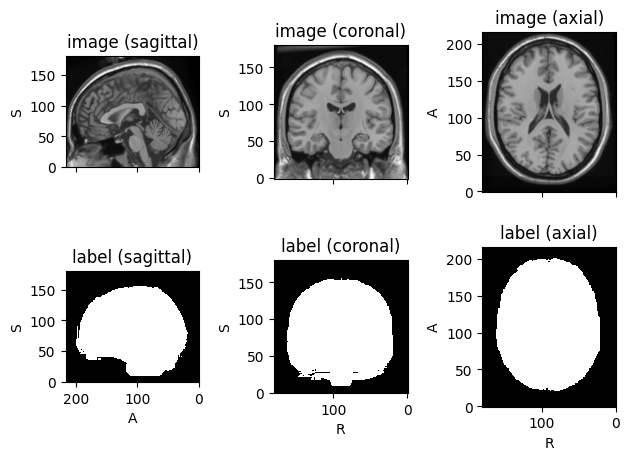

In [36]:
datapoint.plot()

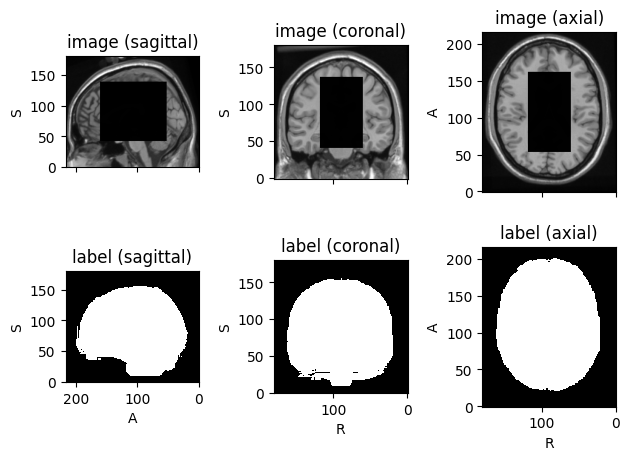

In [37]:
transformed.plot()

Ok, now let's see if it works with ClinicaDL's [CapsDataset]().

Let's download a CAPS structure with which we can work:

In [18]:
!curl -k https://aramislab.paris.inria.fr/clinicadl/files/handbook_2023/data_oasis/CAPS_example.tar.gz -o CAPS_example.tar.gz
!tar xf CAPS_example.tar.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  335M  100  335M    0     0  23.2M      0  0:00:14  0:00:14 --:--:-- 20.3M:00:15 21.3M


In [38]:
caps = CapsDataset(
    caps_directory="data_oasis/CAPS_example",
    preprocessing=T1Linear(),
    transforms=Transforms(
        image_transforms=[RandomHypoIntensity()],
    ),
)
caps.to_tensors("t1_conversion", save_transforms=False)     # conversion to tensors is necessary to manipulate data in a CapsDataset

Creating a TSV file at data_oasis/CAPS_example/overview_t1-linear_cropped.tsv


Converting images and image-specific masks: 100%|██████████| 4/4 [00:01<00:00,  3.50it/s]
Converting common masks: 0it [00:00, ?it/s]


In [39]:
out = caps[0]
out

ImageSample(Keys: ('image', 'label', 'participant', 'session', 'image_path', 'extraction', 'sample_index'); images: 1)

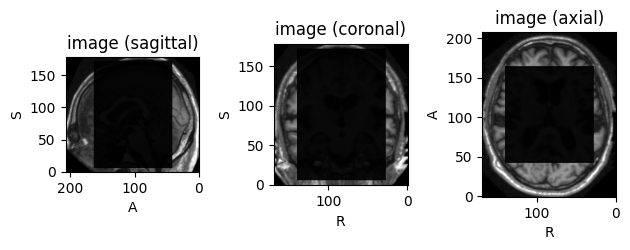

In [42]:
out.plot()

Our transform has effectively been applied to the data! We can also see that by calling the method ``get_applied_transforms``.

In [44]:
out.get_applied_transforms()

[RandomHypoIntensity(min_hypo=0.5)]

Now, we would like to keep track of the mask used to generate the hypointensity, as well as the hypointensity coefficients. To do this, we need to modify our transform to add some information in the ``DataPoints``.

## Add information to a ``DataPoint``

In [47]:
class RandomHypoIntensity(tio.Transform):
    """
    To generate random hypointensities in ClinicaDL.
    """

    def __init__(self, min_hypo: float = 0.5, **kwargs):
        super().__init__(**kwargs)
        self.min_hypo = min_hypo
        self.args_names = ["min_hypo"]

    def apply_transform(self, datapoint: DataPoint) -> DataPoint:
        transformed = deepcopy(datapoint)

        mask = random_mask(datapoint.image.tensor)
        hypo_coeff = random_hypo_coeff(self.min_hypo)

        # apply the hypointensity to all the images in DataPoint (but not the masks because intensity_only=True)
        for image in transformed.get_images(intensity_only=True):
            image.tensor[mask] *= hypo_coeff

        ### save useful data ###
        transformed.add_image(datapoint.image, "original_image")
        transformed.add_mask(
            tio.LabelMap(tensor=mask, affine=datapoint.image.affine), "random_mask"
        )
        transformed["hypo_coeff"] = hypo_coeff
        ######

        return transformed

In [48]:
caps = CapsDataset(
    caps_directory="data_oasis/CAPS_example",
    preprocessing=T1Linear(),
    data="data_oasis/CAPS_example/overview_t1-linear_cropped.tsv",
    transforms=Transforms(
        image_transforms=[RandomHypoIntensity()],
    ),
)
caps.read_tensor_conversion("t1_conversion")

In [49]:
out = caps[0]
out

ImageSample(Keys: ('image', 'label', 'participant', 'session', 'image_path', 'original_image', 'random_mask', 'hypo_coeff', 'extraction', 'sample_index'); images: 3)

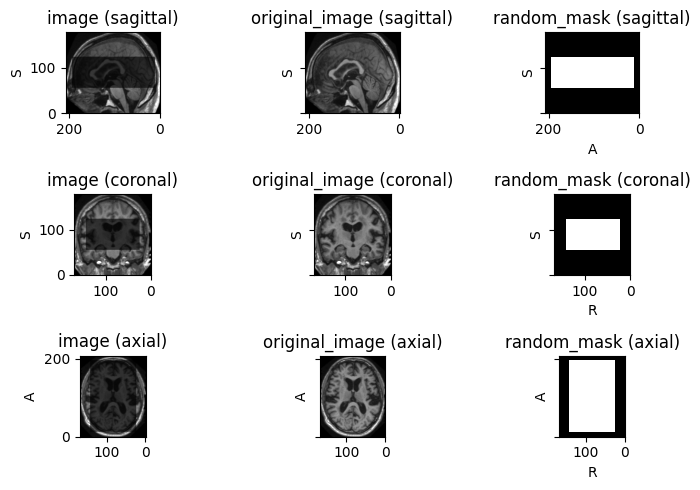

In [50]:
out.plot(figsize=(12,5))

In [51]:
out.hypo_coeff

0.36247654844880756